# Project 3: Multidisciplinary Care and Workforce Utilisation Analysis

## Objective

This project investigates workforce utilisation patterns within NHS primary care appointments across Hertfordshire and West Essex. The analysis examines workforce share, utilisation trends, same-day demand, appointment modes, and appointment outcomes to understand better how different workforce groups contribute to service delivery.

The dataset categorises healthcare professionals as either GPs or Other Practice Staff. The latter may include a range of healthcare professionals, such as nurses, pharmacists, physician assistants, and other multidisciplinary team members, although a detailed breakdown is not provided in the dataset.

## Introduction

This project explores workforce utilisation patterns within NHS primary care appointments across Hertfordshire and West Essex.

The analysis examines how appointment activity is distributed between General Practitioners (GPs) and Other Practice Staff, focusing on workforce share, utilisation trends over time, same-day demand, appointment modes, and appointment outcomes.

The objective is to understand how different workforce groups contribute to service delivery and whether workforce utilisation varies across operational scenarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("../data/Regional_CSV_HertfordshireWEssex.csv")

## Question 1: What proportion of appointments are delivered by each workforce group?

Before exploring workforce utilisation patterns, it is important to understand how appointment activity is distributed across workforce groups. This provides a baseline view of the relative contribution of GPs and Other Practice Staff within primary care.

In [3]:
df["HCP_TYPE"].value_counts()

HCP_TYPE
Other Practice staff    8583
GP                      8232
Unknown                 3229
Name: count, dtype: int64

In [4]:
hcp_volume = (
    df.groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

hcp_volume

HCP_TYPE
GP                      11151727
Other Practice staff     9923554
Unknown                   493557
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [5]:
hcp_pct = (
    hcp_volume / hcp_volume.sum() * 100
).round(2)

hcp_pct

HCP_TYPE
GP                      51.70
Other Practice staff    46.01
Unknown                  2.29
Name: COUNT_OF_APPOINTMENTS, dtype: float64

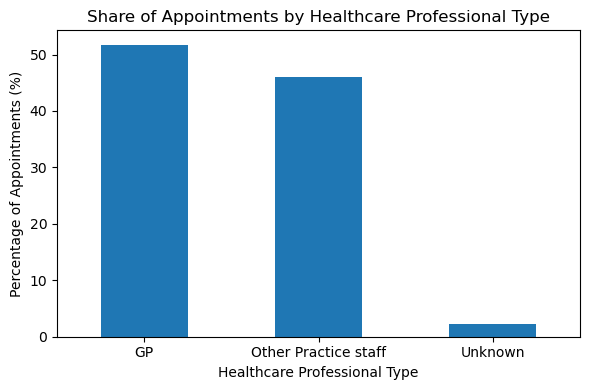

In [6]:
plt.figure(figsize=(6,4))

hcp_pct.plot(kind="bar")

plt.title("Share of Appointments by Healthcare Professional Type")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("Percentage of Appointments (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

GPs delivered 51.7% of all appointments during the study period, while Other Practice Staff delivered 46.0%. The remaining 2.3% of appointments were recorded with an unknown workforce type.

Although GPs accounted for the largest share of activity, the difference between workforce groups was relatively small. This suggests that primary care delivery relies on both GPs and multidisciplinary practice staff rather than being dominated by a single workforce group.

One could argue that GPs still carry the greatest individual workload because "Other Practice Staff" likely includes multiple staff categories combined into a single group, whereas GP activity is reported separately. However, the dataset does not provide a further breakdown of Other Practice Staff, limiting deeper workforce comparisons.

## Question 2: How has workforce utilisation changed over time?

Understanding overall workforce share is useful, but workforce utilisation may vary over time. This analysis explores whether the balance between GPs and Other Practice Staff remained stable throughout the study period.

In [7]:
monthly_hcp = (
    df.groupby(["APPOINTMENT_MONTH", "HCP_TYPE"])
    ["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

monthly_hcp.head()

,APPOINTMENT_MONTH,HCP_TYPE,COUNT_OF_APPOINTMENTS
0,APR2024,GP,356585
1,APR2024,Other Practice staff,325723
2,APR2024,Unknown,16798
3,APR2025,GP,348963
4,APR2025,Other Practice staff,305205


In [8]:
monthly_hcp["APPOINTMENT_MONTH"] = pd.to_datetime(
    monthly_hcp["APPOINTMENT_MONTH"],
    format="%b%Y"
)

In [9]:
monthly_hcp_clean = monthly_hcp[
    monthly_hcp["HCP_TYPE"] != "Unknown"
]

In [10]:
monthly_pct = (
    monthly_hcp_clean
    .pivot(
        index="APPOINTMENT_MONTH",
        columns="HCP_TYPE",
        values="COUNT_OF_APPOINTMENTS"
    )
)

monthly_pct.head()

HCP_TYPE,GP,Other Practice staff
APPOINTMENT_MONTH,,
2023-10-01,388865,383798
2023-11-01,380924,328111
2023-12-01,324417,262344
2024-01-01,400309,337654
2024-02-01,372039,324508


In [11]:
monthly_pct = (
    monthly_pct.div(monthly_pct.sum(axis=1), axis=0)
    * 100
).round(2)

monthly_pct.head()

HCP_TYPE,GP,Other Practice staff
APPOINTMENT_MONTH,,
2023-10-01,50.33,49.67
2023-11-01,53.72,46.28
2023-12-01,55.29,44.71
2024-01-01,54.25,45.75
2024-02-01,53.41,46.59


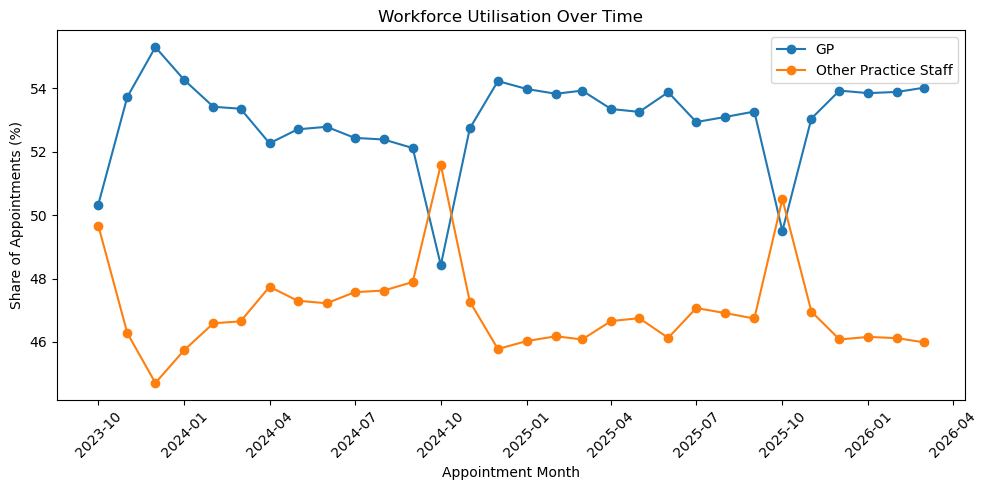

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_pct.index,
    monthly_pct["GP"],
    marker="o",
    label="GP"
)

plt.plot(
    monthly_pct.index,
    monthly_pct["Other Practice staff"],
    marker="o",
    label="Other Practice Staff"
)

plt.title("Workforce Utilisation Over Time")
plt.xlabel("Appointment Month")
plt.ylabel("Share of Appointments (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Finding

Workforce utilisation remained relatively stable throughout the study period. GPs consistently delivered approximately 52–54% of appointments, while Other Practice Staff accounted for roughly 46–48%.

No clear long-term shift toward either workforce group was observed. However, temporary increases in the share of appointments delivered by Other Practice Staff were observed during October 2024 and October 2025, when their contribution briefly exceeded that of GPs.

Overall, the findings suggest that multidisciplinary teams play a sustained and substantial role in primary care delivery, rather than representing a growing or declining share of activity over time.

## Question 3: Which workforce group handles the most same-day demand?

Same-day appointments are often associated with urgent healthcare needs. This question examines whether immediate demand is evenly shared across workforce groups or falls more heavily on specific staff types.

In [13]:
same_day = df[
    df["TIME_BETWEEN_BOOK_AND_APPT"] == "Same Day"
]

In [14]:
same_day_volume = (
    same_day.groupby("HCP_TYPE")
    ["COUNT_OF_APPOINTMENTS"]
    .sum()
)

same_day_volume

HCP_TYPE
GP                      6168149
Other Practice staff    3212747
Unknown                  357358
Name: COUNT_OF_APPOINTMENTS, dtype: int64

In [15]:
same_day_pct = (
    same_day_volume / same_day_volume.sum() * 100
).round(2)

same_day_pct

HCP_TYPE
GP                      63.34
Other Practice staff    32.99
Unknown                  3.67
Name: COUNT_OF_APPOINTMENTS, dtype: float64

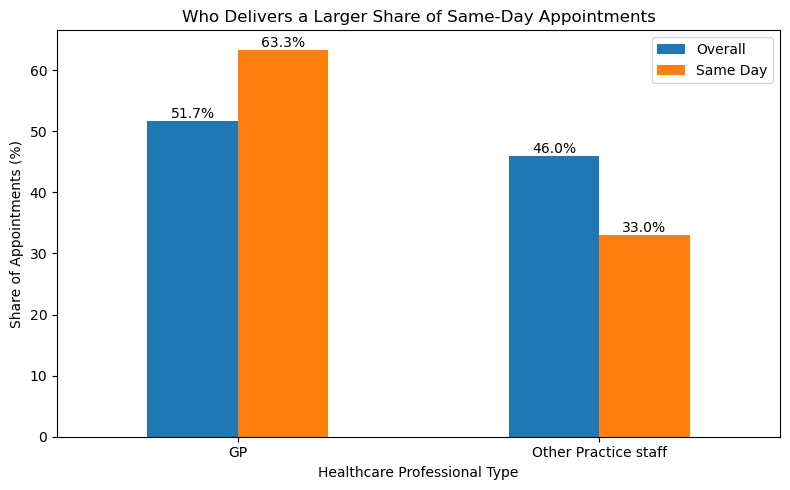

In [16]:
comparison = pd.DataFrame({
    "Overall": hcp_pct,
    "Same Day": same_day_pct
})

comparison = comparison.drop("Unknown")

ax = comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Who Delivers a Larger Share of Same-Day Appointments")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("Share of Appointments (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### Finding

Workforce utilisation differed substantially when focusing specifically on same-day appointments.

Across all appointments, GPs accounted for 51.7% of activity, compared with 46.0% for Other Practice Staff. However, for same-day appointments, GP involvement increased to 63.3%, while Other Practice Staff accounted for 33.0%.

This suggests that immediate or urgent demand relies more heavily on GP capacity than routine appointment activity. While multidisciplinary teams contribute significantly to overall primary care delivery, GPs appear to play a central role in managing same-day access. It is important to note, however, that Other Practice Staff collectively accounted for 46.0% of all appointments and represent multiple professional groups rather than a single profession, meaning direct comparisons with GPs should be interpreted with caution.

## Question 4: Do appointment modes differ by workforce group?

Appointments can be delivered via a range of consultation methods, including face-to-face, telephone, and online. This analysis investigates whether workforce groups utilise these appointment modes differently.

In [17]:
mode_hcp = (
    df.groupby(["HCP_TYPE", "APPT_MODE"])
    ["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

mode_hcp.head()

,HCP_TYPE,APPT_MODE,COUNT_OF_APPOINTMENTS
0,GP,Face-to-Face,6965626
1,GP,Home Visit,93493
2,GP,Telephone,3224746
3,GP,Unknown,126247
4,GP,Video/Online,741615


In [18]:
mode_pct = (
    mode_hcp.pivot(
        index="HCP_TYPE",
        columns="APPT_MODE",
        values="COUNT_OF_APPOINTMENTS"
    )
)

mode_pct

APPT_MODE,Face-to-Face,Home Visit,Telephone,Unknown,Video/Online
HCP_TYPE,,,,,
GP,6965626,93493,3224746,126247,741615
Other Practice staff,7447461,74699,1881502,115810,404082
Unknown,51157,12806,10466,417971,1157


In [19]:
mode_pct = (
    mode_pct.div(mode_pct.sum(axis=1), axis=0)
    * 100
).round(2)

mode_pct

APPT_MODE,Face-to-Face,Home Visit,Telephone,Unknown,Video/Online
HCP_TYPE,,,,,
GP,62.46,0.84,28.92,1.13,6.65
Other Practice staff,75.05,0.75,18.96,1.17,4.07
Unknown,10.36,2.59,2.12,84.69,0.23


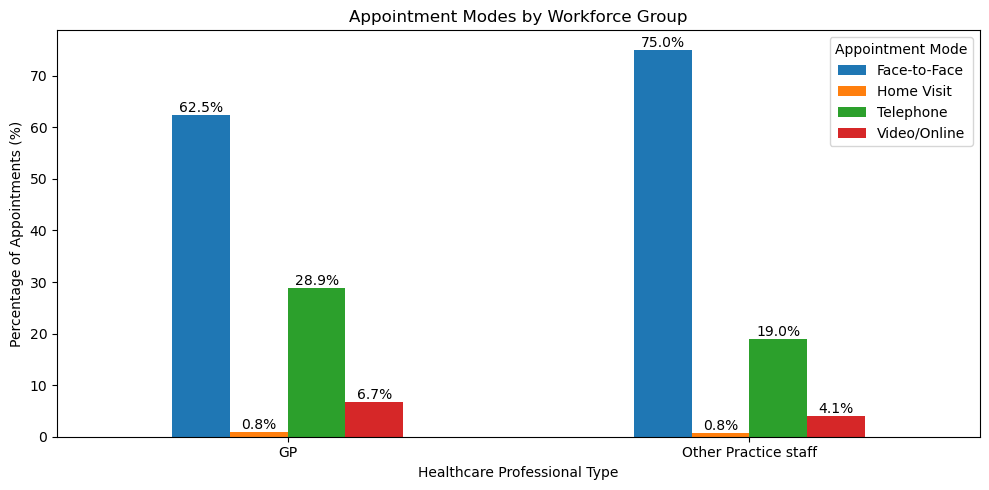

In [20]:
mode_chart = mode_pct.drop(
    index="Unknown",
    columns="Unknown"
)

ax = mode_chart.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Appointment Modes by Workforce Group")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("Percentage of Appointments (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.xticks(rotation=0)
plt.legend(title="Appointment Mode")

plt.tight_layout()
plt.show()

### Finding

Appointment modes differed noticeably between workforce groups.

Other Practice Staff delivered a higher proportion of appointments face-to-face (75.1%) compared with GPs (62.5%). In contrast, GPs relied more heavily on telephone consultations, which accounted for 28.9% of appointments compared with 19.0% for Other Practice Staff.

Video and online appointments represented a relatively small proportion of activity for both workforce groups, while home visits accounted for less than 1% of appointments.

These findings suggest that workforce groups are utilised differently within primary care, with Other Practice Staff appearing to provide a greater proportion of in-person care while GPs make greater use of remote consultation methods.

## Question 5: Which workforce group experiences the highest DNA rates?

Patient non-attendance can affect service efficiency and appointment availability. This question explores whether DNA rates differ between workforce groups and whether appointment outcomes vary across staff types.

In [21]:
hcp_status = (
    df.groupby(["HCP_TYPE", "APPT_STATUS"])
    ["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

hcp_status

,HCP_TYPE,APPT_STATUS,COUNT_OF_APPOINTMENTS
0,GP,Attended,10262155
1,GP,DNA,274705
2,GP,Unknown,614867
3,Other Practice staff,Attended,8716280
4,Other Practice staff,DNA,507163
5,Other Practice staff,Unknown,700111
6,Unknown,Attended,424028
7,Unknown,DNA,5659
8,Unknown,Unknown,63870


In [22]:
hcp_status_pct = (
    hcp_status.pivot(
        index="HCP_TYPE",
        columns="APPT_STATUS",
        values="COUNT_OF_APPOINTMENTS"
    )
)

hcp_status_pct

APPT_STATUS,Attended,DNA,Unknown
HCP_TYPE,,,
GP,10262155,274705,614867
Other Practice staff,8716280,507163,700111
Unknown,424028,5659,63870


In [23]:
hcp_status_pct = (
    hcp_status_pct.div(
        hcp_status_pct.sum(axis=1),
        axis=0
    )
    * 100
).round(2)

hcp_status_pct

APPT_STATUS,Attended,DNA,Unknown
HCP_TYPE,,,
GP,92.02,2.46,5.51
Other Practice staff,87.83,5.11,7.06
Unknown,85.91,1.15,12.94


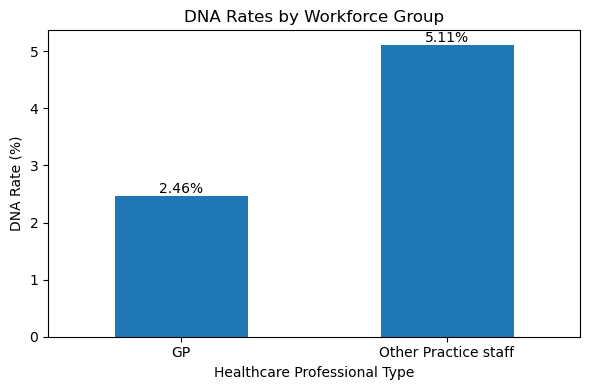

In [24]:
dna_rates = hcp_status_pct.loc[
    ["GP", "Other Practice staff"],
    "DNA"
]

ax = dna_rates.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("DNA Rates by Workforce Group")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("DNA Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Finding

DNA rates differed substantially between workforce groups.

Appointments delivered by GPs recorded a DNA rate of 2.46%, compared with 5.11% for Other Practice Staff. This means that appointments associated with Other Practice Staff experienced a DNA rate more than double that observed for GP appointments.

This finding suggests that appointment outcomes vary by workforce group. While GPs and Other Practice Staff deliver similar proportions of overall activity, attendance patterns differ considerably, with appointments delivered by Other Practice Staff associated with a higher likelihood of non-attendance.

## Conclusion

This analysis found that primary care activity was shared relatively evenly between GPs and Other Practice Staff, with workforce utilisation remaining stable throughout the study period.

However, workforce utilisation varied considerably when examining specific operational scenarios. GPs played a greater role in delivering same-day appointments, while Other Practice Staff delivered a larger proportion of care through face-to-face consultations. These findings suggest that different workforce groups fulfil distinct operational roles within primary care delivery.

The most notable finding was a difference in DNA rates: appointments delivered by Other Practice Staff had more than double the DNA rate observed for GP appointments. This highlights the importance of considering appointment outcomes alongside workforce activity when evaluating service performance.

Overall, the analysis demonstrates that multidisciplinary teams make a substantial contribution to NHS primary care delivery, while GPs continue to play a critical role in urgent access and appointment management.

## Key Findings

- GPs delivered 51.7% of all appointments, compared with 46.0% for Other Practice Staff.
- Workforce utilisation remained stable throughout the study period.
- October repeatedly showed unusual utilisation patterns across multiple years.
- GPs delivered 63.3% of same-day appointments, indicating a greater role in urgent demand.
- Other Practice Staff delivered a higher proportion of appointments face-to-face (75.1%).
- GP appointments relied more heavily on telephone consultations (28.9%).
- Appointments delivered by Other Practice Staff recorded a DNA rate of 5.11%, compared with 2.46% for GP appointments.
- Other Practice Staff experienced more than double the DNA rate observed for GP appointments.